# Data Engineering

1. Importing all required libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')  # suppress minor warnings for clean output
import os

# Navigate up one level from notebooks/ to project root
os.chdir('..')


In [2]:
# Set global plot style — makes ALL charts look professional
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

print("All libraries imported successfully !")

All libraries imported successfully !


2. Loading Dataset

In [3]:
df = pd.read_csv('data\global_health_statistics.csv')

In [4]:

print(" Dataset Shape:", df.shape)

 Dataset Shape: (1000000, 22)


In [5]:
print("\n Column Names:", df.columns.tolist())



 Column Names: ['Country', 'Year', 'Disease Name', 'Disease Category', 'Prevalence Rate (%)', 'Incidence Rate (%)', 'Mortality Rate (%)', 'Age Group', 'Gender', 'Population Affected', 'Healthcare Access (%)', 'Doctors per 1000', 'Hospital Beds per 1000', 'Treatment Type', 'Average Treatment Cost (USD)', 'Availability of Vaccines/Treatment', 'Recovery Rate (%)', 'DALYs', 'Improvement in 5 Years (%)', 'Per Capita Income (USD)', 'Education Index', 'Urbanization Rate (%)']


In [6]:
print("\n First 5 rows:", df.head())


 First 5 rows:      Country  Year         Disease Name Disease Category  Prevalence Rate (%)  \
0      Italy  2013              Malaria      Respiratory                 0.95   
1     France  2002                Ebola        Parasitic                12.46   
2     Turkey  2015             COVID-19          Genetic                 0.91   
3  Indonesia  2011  Parkinson's Disease       Autoimmune                 4.68   
4      Italy  2013         Tuberculosis          Genetic                 0.83   

   Incidence Rate (%)  Mortality Rate (%) Age Group Gender  \
0                1.55                8.42      0-18   Male   
1                8.63                8.75       61+   Male   
2                2.35                6.22     36-60   Male   
3                6.29                3.99      0-18  Other   
4               13.59                7.01       61+   Male   

   Population Affected  ...  Hospital Beds per 1000  Treatment Type  \
0               471007  ...                    7.58  

3. Data Inspection

In [7]:
print("Data types:", df.dtypes)

Data types: Country                                object
Year                                    int64
Disease Name                           object
Disease Category                       object
Prevalence Rate (%)                   float64
Incidence Rate (%)                    float64
Mortality Rate (%)                    float64
Age Group                              object
Gender                                 object
Population Affected                     int64
Healthcare Access (%)                 float64
Doctors per 1000                      float64
Hospital Beds per 1000                float64
Treatment Type                         object
Average Treatment Cost (USD)            int64
Availability of Vaccines/Treatment     object
Recovery Rate (%)                     float64
DALYs                                   int64
Improvement in 5 Years (%)            float64
Per Capita Income (USD)                 int64
Education Index                       float64
Urbanization Rate (%) 

In [8]:
print("Missing Values (count + percentage)")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])

Missing Values (count + percentage)
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [9]:
print("Basic Statistics", df.describe())

Basic Statistics                  Year  Prevalence Rate (%)  Incidence Rate (%)  \
count  1000000.000000       1000000.000000      1000000.000000   
mean      2011.996999            10.047992            7.555005   
std          7.217287             5.740189            4.298947   
min       2000.000000             0.100000            0.100000   
25%       2006.000000             5.090000            3.840000   
50%       2012.000000            10.040000            7.550000   
75%       2018.000000            15.010000           11.280000   
max       2024.000000            20.000000           15.000000   

       Mortality Rate (%)  Population Affected  Healthcare Access (%)  \
count      1000000.000000       1000000.000000         1000000.000000   
mean             5.049919        500735.427363              74.987835   
std              2.859427        288660.116648              14.436345   
min              0.100000          1000.000000              50.000000   
25%              2.5800

In [10]:
print("Unique Value Counts (categorical columns)")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(5))
    print()

Unique Value Counts (categorical columns)
Country: 20 unique values
Country
Russia          50532
South Africa    50408
South Korea     50181
Germany         50176
UK              50125
Name: count, dtype: int64

Disease Name: 20 unique values
Disease Name
COVID-19    50404
Zika        50313
Dengue      50289
Cancer      50285
HIV/AIDS    50274
Name: count, dtype: int64

Disease Category: 11 unique values
Disease Category
Metabolic       91332
Parasitic       91178
Genetic         91153
Autoimmune      91153
Neurological    91000
Name: count, dtype: int64

Age Group: 4 unique values
Age Group
19-35    251201
61+      249989
0-18     249605
36-60    249205
Name: count, dtype: int64

Gender: 3 unique values
Gender
Male      333676
Female    333223
Other     333101
Name: count, dtype: int64

Treatment Type: 4 unique values
Treatment Type
Surgery        250528
Therapy        250263
Vaccination    249753
Medication     249456
Name: count, dtype: int64

Availability of Vaccines/Treatment: 2 

4. Data Cleaning

In [11]:
df_clean = df.copy()

In [12]:
# Standardize Column Names
df_clean.columns = (df_clean.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(' ', '_')
                    .str.replace('(', '')
                    .str.replace(')', ''))

print("Cleaned column names:", df_clean.columns.tolist())


Cleaned column names: ['country', 'year', 'disease_name', 'disease_category', 'prevalence_rate_%', 'incidence_rate_%', 'mortality_rate_%', 'age_group', 'gender', 'population_affected', 'healthcare_access_%', 'doctors_per_1000', 'hospital_beds_per_1000', 'treatment_type', 'average_treatment_cost_usd', 'availability_of_vaccines/treatment', 'recovery_rate_%', 'dalys', 'improvement_in_5_years_%', 'per_capita_income_usd', 'education_index', 'urbanization_rate_%']


In [13]:
# Handle Missing Values
num_cols = df_clean.select_dtypes(include=np.number).columns
cat_cols = df_clean.select_dtypes(include='object').columns

for col in num_cols:
    missing_pct = df_clean[col].isnull().mean() * 100
    if missing_pct > 0:
        if missing_pct < 5:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"  {col}: filled {missing_pct:.1f}% nulls with MEDIAN")
        else:
            df_clean[col].fillna(df_clean[col].mean(), inplace=True)
            print(f"  {col}: filled {missing_pct:.1f}% nulls with MEAN")

for col in cat_cols:
    df_clean[col].fillna('Unknown', inplace=True)

In [14]:
# Removing duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f"\n Removed {before - after} duplicate rows")



 Removed 0 duplicate rows


In [15]:
# Fixing data types
if 'year' in df_clean.columns:
    df_clean['year'] = df_clean['year'].astype(int)

print(f"\n Final clean dataset shape: {df_clean.shape}")


 Final clean dataset shape: (1000000, 22)


5. Feature Engineering

In [16]:
# Run this to see exact column names in YOUR dataset
print("Exact Column Names:")
for i, col in enumerate(df_clean.columns):
    print(f"  [{i}] '{col}'")

Exact Column Names:
  [0] 'country'
  [1] 'year'
  [2] 'disease_name'
  [3] 'disease_category'
  [4] 'prevalence_rate_%'
  [5] 'incidence_rate_%'
  [6] 'mortality_rate_%'
  [7] 'age_group'
  [8] 'gender'
  [9] 'population_affected'
  [10] 'healthcare_access_%'
  [11] 'doctors_per_1000'
  [12] 'hospital_beds_per_1000'
  [13] 'treatment_type'
  [14] 'average_treatment_cost_usd'
  [15] 'availability_of_vaccines/treatment'
  [16] 'recovery_rate_%'
  [17] 'dalys'
  [18] 'improvement_in_5_years_%'
  [19] 'per_capita_income_usd'
  [20] 'education_index'
  [21] 'urbanization_rate_%'


In [17]:
#Feature 1: region
region_map = {
    'South Africa': 'Africa',    'Nigeria':    'Africa',
    'South Korea':  'Asia',      'China':      'Asia',
    'Saudi Arabia': 'Asia',      'Japan':      'Asia',
    'India':        'Asia',      'Indonesia':  'Asia',
    'Turkey':       'Asia',      'Russia':     'Europe',
    'Germany':      'Europe',    'UK':         'Europe',
    'France':       'Europe',    'Italy':      'Europe',
    'USA':          'North America', 'Canada': 'North America',
    'Mexico':       'North America','Brazil':  'South America',
    'Argentina':    'South America','Australia':'Oceania',
}
df_clean['region'] = df_clean['country'].map(region_map)
print(" Feature 1: region")

 Feature 1: region


In [18]:
#Feature 2: Treatment Access Gap 
df_clean['treatment_access_gap'] = (
    df_clean['prevalence_rate_%'] - df_clean['healthcare_access_%']
).round(2)
print("Feature 2: treatment_access_gap")

Feature 2: treatment_access_gap


In [19]:
#Feature 3: Healthcare Infrastructure Score
df_clean['healthcare_infrastructure_score'] = (
    (df_clean['doctors_per_1000'] * 0.5) +
    (df_clean['hospital_beds_per_1000'] * 0.5)
).round(2)
print(" Feature 3: healthcare_infrastructure_score")

 Feature 3: healthcare_infrastructure_score


In [20]:
#Feature 4: Disease Burden Score
df_clean['disease_burden_score'] = (
    (df_clean['prevalence_rate_%'] * 0.4) +
    (df_clean['mortality_rate_%'] * 0.4) +
    (df_clean['dalys'] / df_clean['dalys'].max() * 100 * 0.2)
).round(2)
print("Feature 4: disease_burden_score")

Feature 4: disease_burden_score


In [21]:
#Feature 5: Economic Health Index 
df_clean['economic_health_index'] = (
    (df_clean['per_capita_income_usd'] /
     df_clean['per_capita_income_usd'].max() * 100 * 0.5) +
    (df_clean['healthcare_access_%'] * 0.5)
).round(2)
print(" Feature 5: economic_health_index")

 Feature 5: economic_health_index


In [22]:
#Feature 6: Decade
df_clean['decade'] = (
    (df_clean['year'] // 10 * 10).astype(str) + 's'
)
print("Feature 6: decade")

Feature 6: decade


In [23]:
#Feature 7: Vaccine Available (binary) 
df_clean['vaccine_available'] = (
    df_clean['availability_of_vaccines/treatment']
    .str.lower()
    .str.contains('yes', na=False)
    .astype(int)
)
print("Feature 7: vaccine_available")

Feature 7: vaccine_available


In [24]:
# Verifing ALL features created successfully 
new_features = ['region', 'treatment_access_gap',
                'healthcare_infrastructure_score',
                'disease_burden_score',
                'economic_health_index',
                'decade', 'vaccine_available']

all_good = all(f in df_clean.columns for f in new_features)
if all_good:
    print("ALL 7 features created successfully!")
    print(f"Dataset now has {len(df_clean.columns)} columns")
    print(f"Dataset shape: {df_clean.shape}")
    print("\nSample of new features:")
    print(df_clean[new_features].head(3))
else:
    missing = [f for f in new_features if f not in df_clean.columns]
    print(f" These features failed: {missing}")

ALL 7 features created successfully!
Dataset now has 29 columns
Dataset shape: (1000000, 29)

Sample of new features:
   region  treatment_access_gap  healthcare_infrastructure_score  \
0  Europe                -56.79                             5.46   
1  Europe                -76.75                             3.22   
2    Asia                -55.50                             3.78   

   disease_burden_score  economic_health_index decade  vaccine_available  
0                 21.72                  37.31  2010s                  0  
1                 17.95                  84.92  2000s                  1  
2                  3.02                  34.33  2010s                  1  


6. Aggregation & Reshaping

In [25]:
# Aggregation 1: By Region + Year
region_year = (df_clean
    .groupby(['region', 'year'])
    .agg(
        avg_mortality=('mortality_rate_%', 'mean'),
        avg_prevalence=('prevalence_rate_%', 'mean'),
        avg_treatment=('healthcare_access_%', 'mean'),
        total_cases=('prevalence_rate_%', 'sum')
    )
    .reset_index()
)
print("region_year aggregation:", region_year.shape)

region_year aggregation: (150, 6)


In [26]:
# Aggregation 2: By Disease Types 
disease_summary = (df_clean
    .groupby('disease_name')
    .agg(
        avg_burden=('disease_burden_score', 'mean'),
        avg_treatment_gap=('treatment_access_gap', 'mean'),
        country_count=('country', 'nunique')
    )
    .reset_index()
    .sort_values('avg_burden', ascending=False)
)
print(" disease_summary aggregation:", disease_summary.shape)

 disease_summary aggregation: (20, 4)


In [27]:
# Aggregation 3: Country-level summary 
country_summary = (df_clean
    .groupby('country')
    .agg(
        avg_mortality=('mortality_rate_%', 'mean'),
        avg_burden=('disease_burden_score', 'mean'),
        avg_treatment_gap=('treatment_access_gap', 'mean')
    )
    .reset_index()
)
print("country_summary aggregation:", country_summary.shape)

country_summary aggregation: (20, 4)


In [28]:
# Pivot Table: Disease × Region 
pivot_disease_region = df_clean.pivot_table(
    values='disease_burden_score',
    index='disease_name',
    columns='region',
    aggfunc='mean'
).round(2)
print("Pivot table shape:", pivot_disease_region.shape)

Pivot table shape: (20, 6)


# Exploratory Data Analysis

In [29]:
project_root = os.path.dirname(os.getcwd())

# Define figures path
figures_path = os.path.join(project_root, 'outputs', 'figures')

# Create the folder if it doesn't exist
os.makedirs(figures_path, exist_ok=True)

print(f"Figures will be saved to: {figures_path}")

Figures will be saved to: c:\Users\sthsu\OneDrive\Desktop\outputs\figures


### Chart 1: Distribution (Histogram)

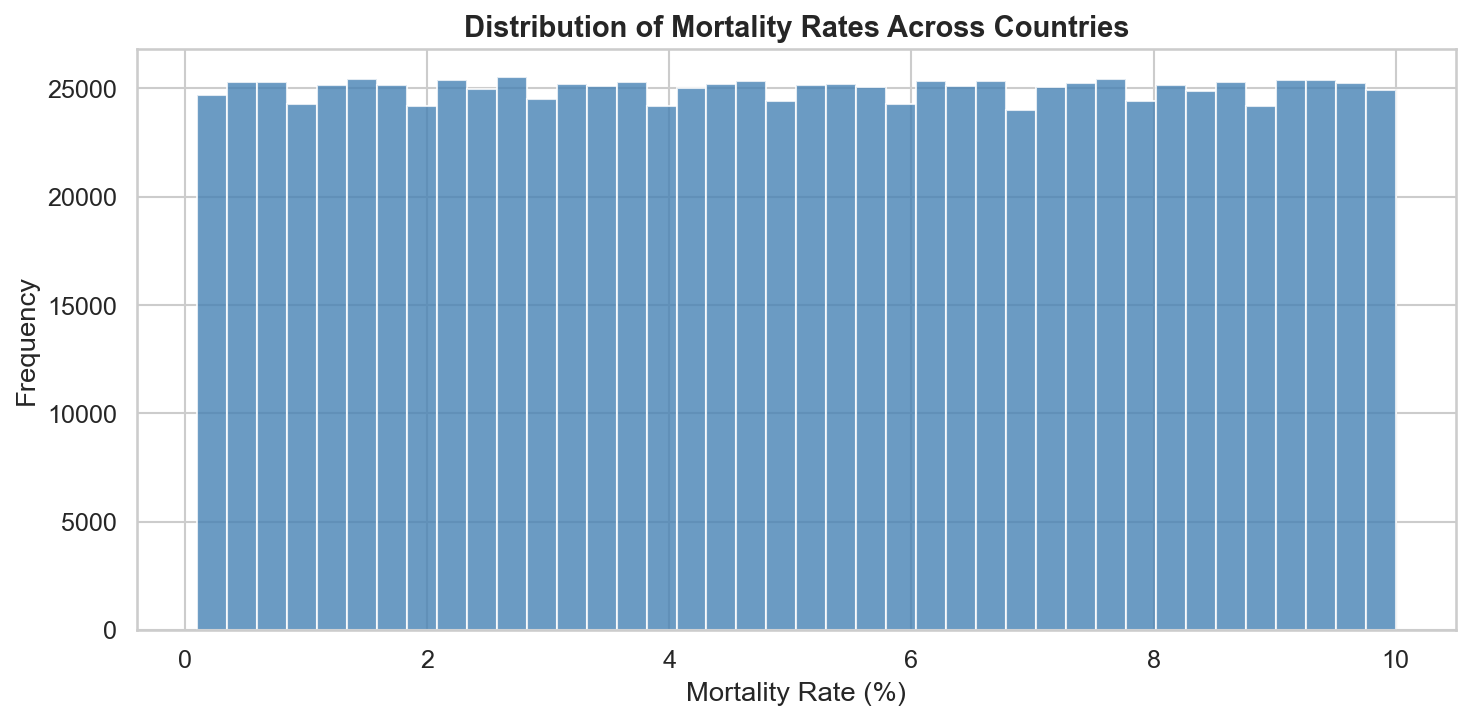

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['mortality_rate_%'], bins=40, 
        color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribution of Mortality Rates Across Countries', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mortality Rate (%)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, '01_mortality_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### Chart 2: Time Series Line Chart

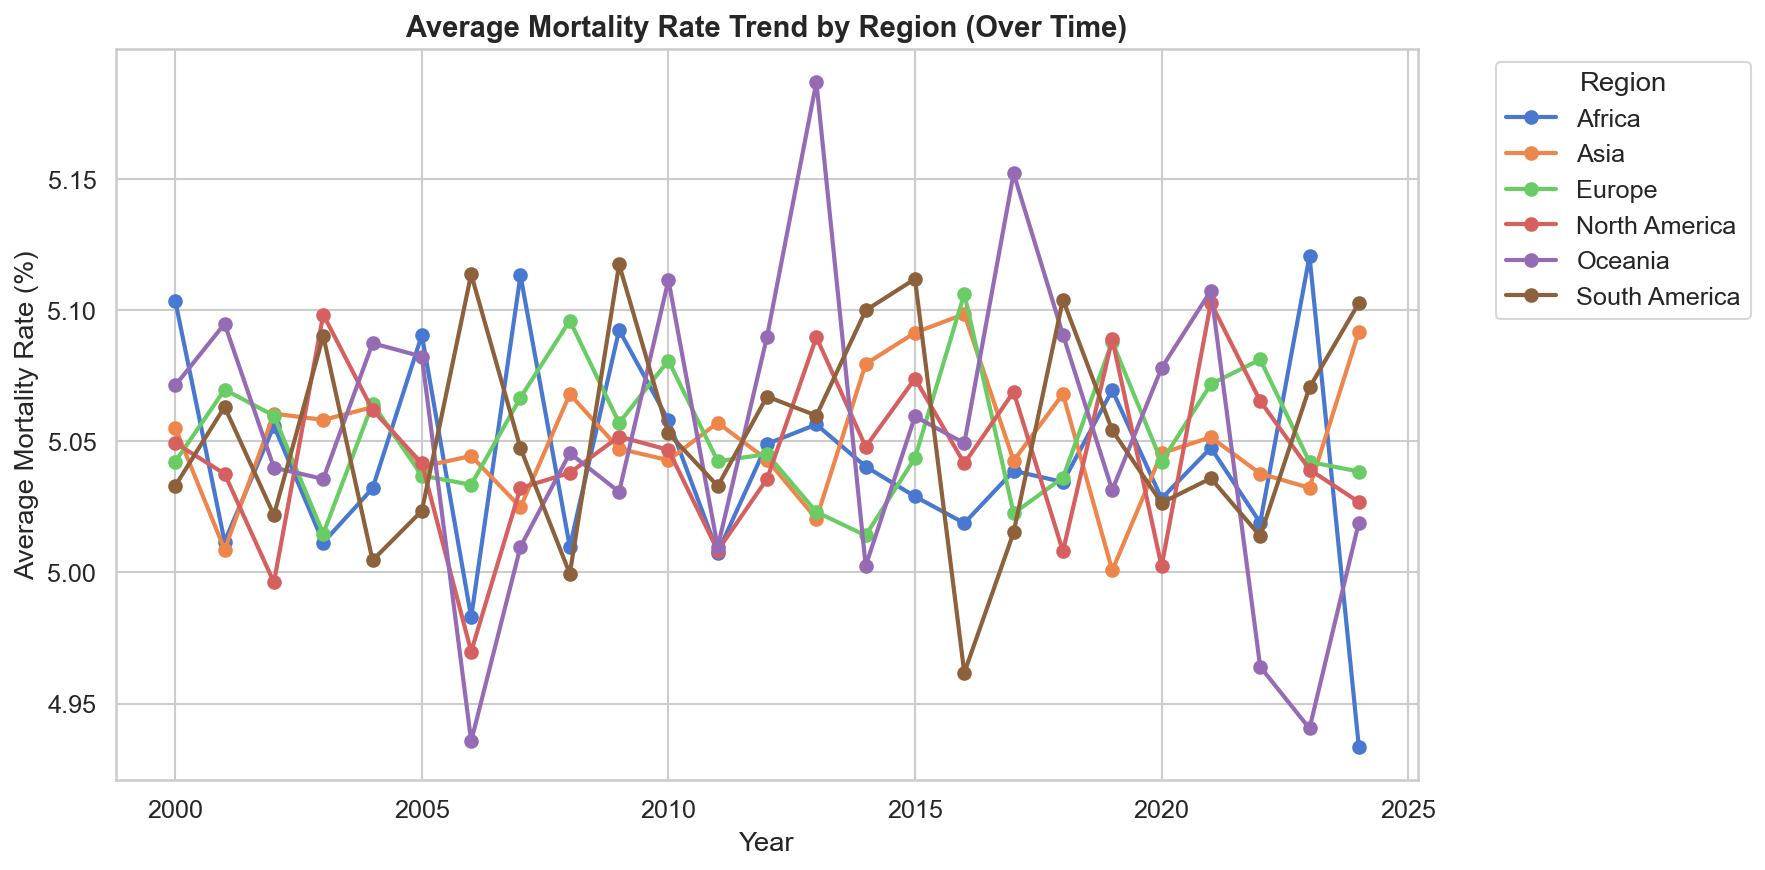

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
for region in region_year['region'].unique():
    data = region_year[region_year['region'] == region]
    ax.plot(data['year'], data['avg_mortality'], 
            marker='o', linewidth=2, label=region)
ax.set_title('Average Mortality Rate Trend by Region (Over Time)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Mortality Rate (%)')
ax.legend(title='Region', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(os.path.join(figures_path, '02_mortality_region_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: Heatmap

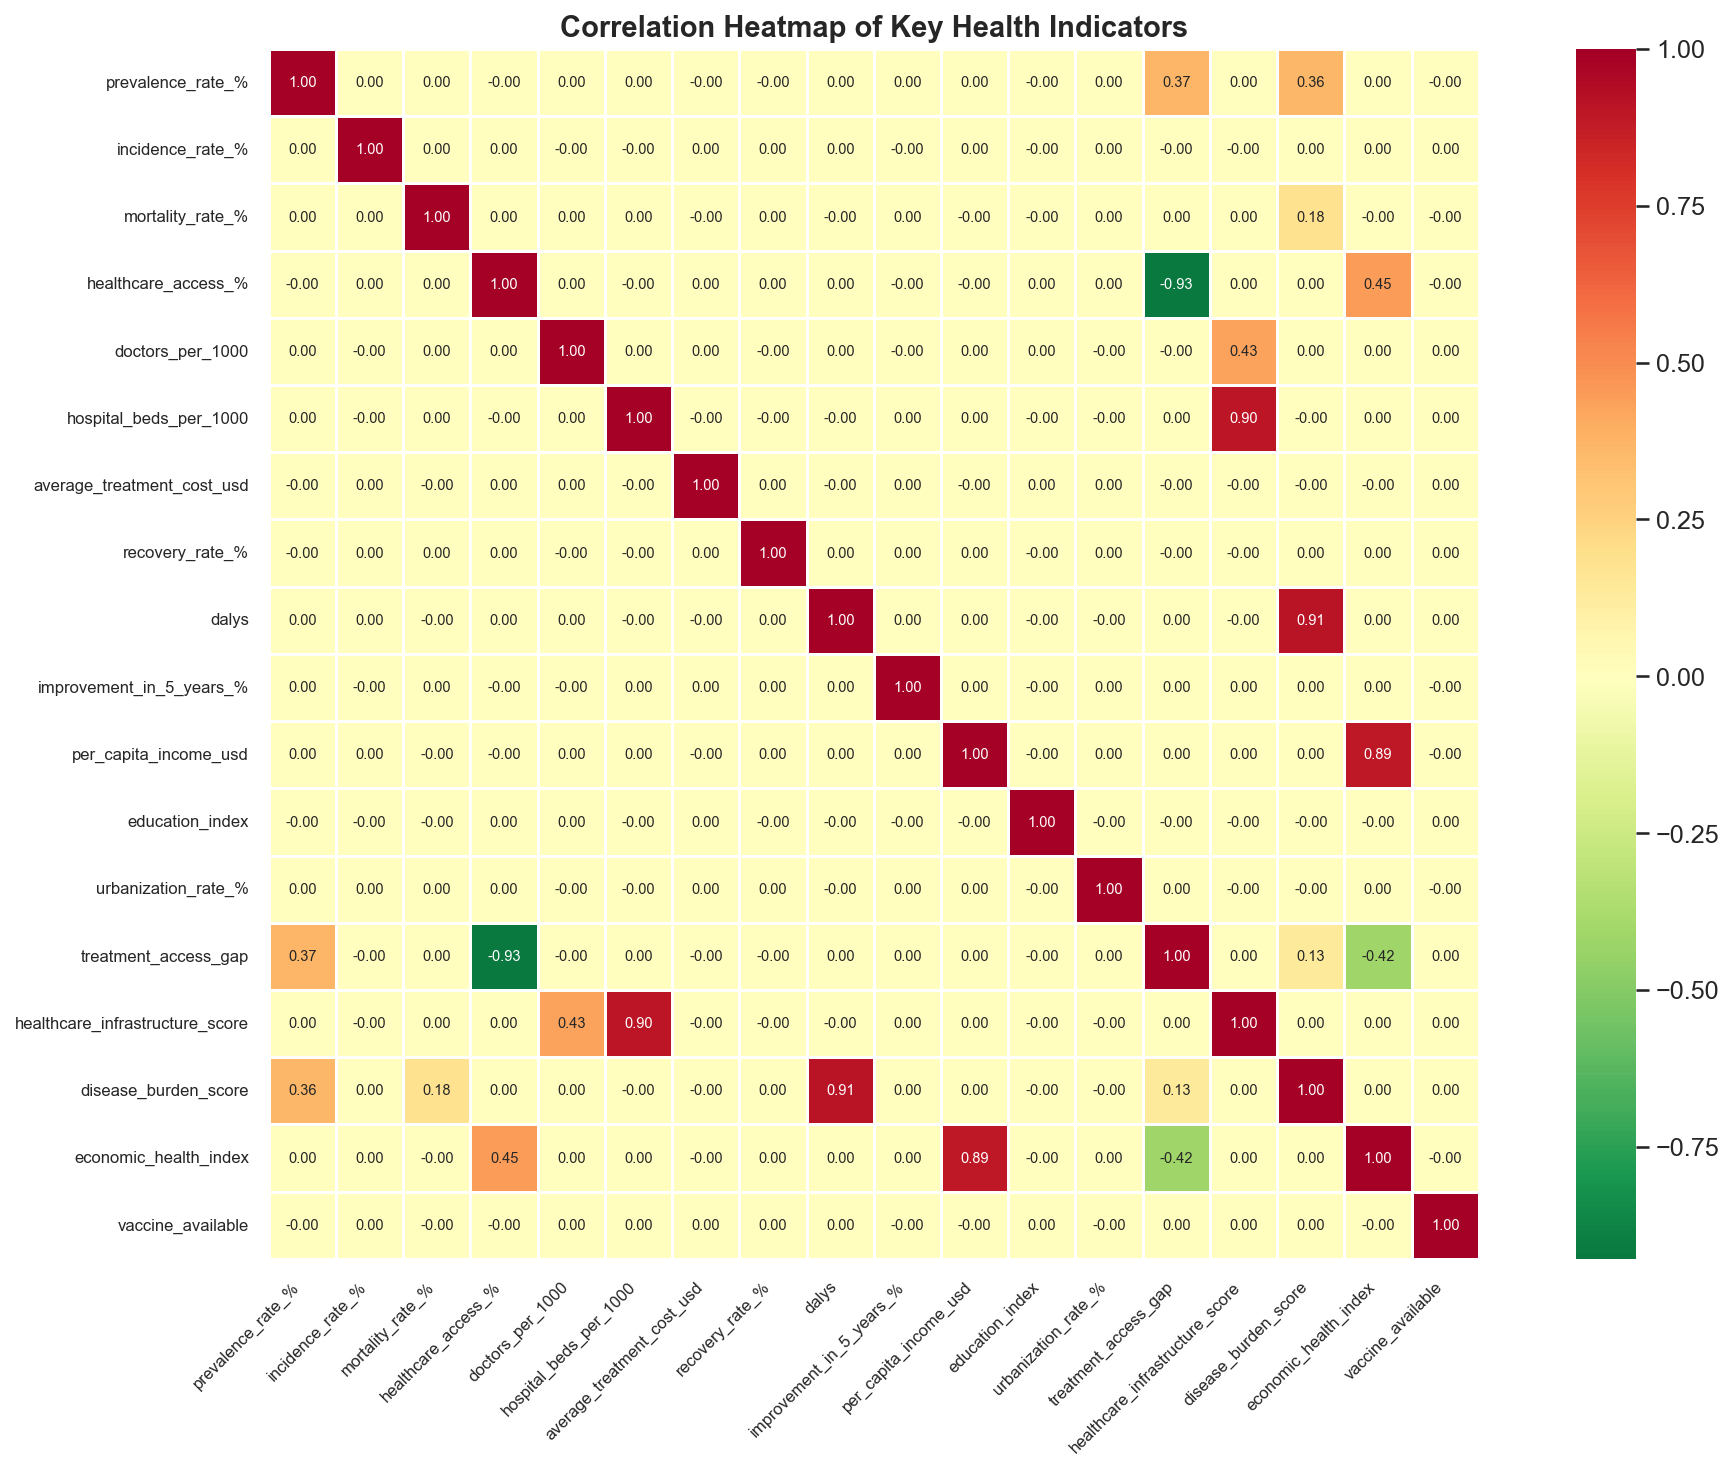

In [32]:
corr_matrix = df_clean[[
    'prevalence_rate_%',
    'incidence_rate_%',
    'mortality_rate_%',
    'healthcare_access_%',
    'doctors_per_1000',
    'hospital_beds_per_1000',
    'average_treatment_cost_usd',
    'recovery_rate_%',
    'dalys',
    'improvement_in_5_years_%',
    'per_capita_income_usd',
    'education_index',
    'urbanization_rate_%',
    'treatment_access_gap',
    'healthcare_infrastructure_score',
    'disease_burden_score',
    'economic_health_index',
    'vaccine_available'
]].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Correlation Heatmap of Key Health Indicators',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, '03_correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

###  Chart 4: Box Plot - Treatment Access Gap by Region

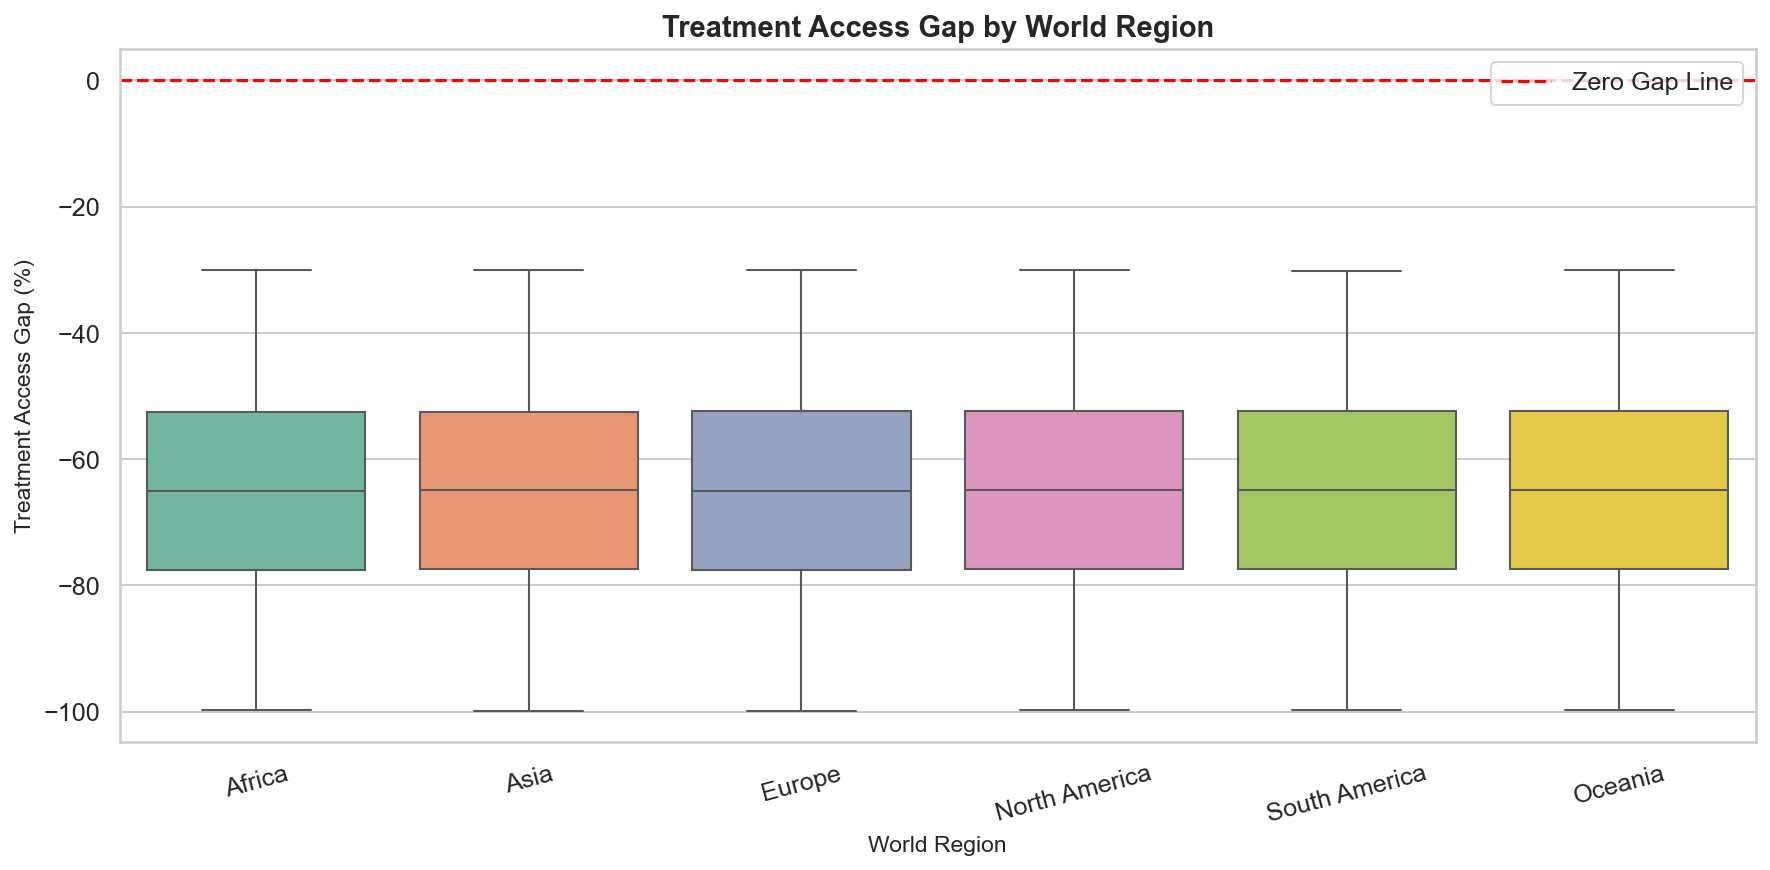

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_clean,
    x='region',
    y='treatment_access_gap',
    palette='Set2',
    order=['Africa', 'Asia', 'Europe', 
           'North America', 'South America', 'Oceania'],
    ax=ax
)
# Add a horizontal reference line at 0
ax.axhline(y=0, color='red', linestyle='--', 
           linewidth=1.5, label='Zero Gap Line')

ax.set_title('Treatment Access Gap by World Region',
             fontsize=14, fontweight='bold')
ax.set_xlabel('World Region', fontsize=11)
ax.set_ylabel('Treatment Access Gap (%)', fontsize=11)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, '04_treatment_gap_boxplot.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### Chart 5: Bar Chart - Top 15 Diseases by Burden Score

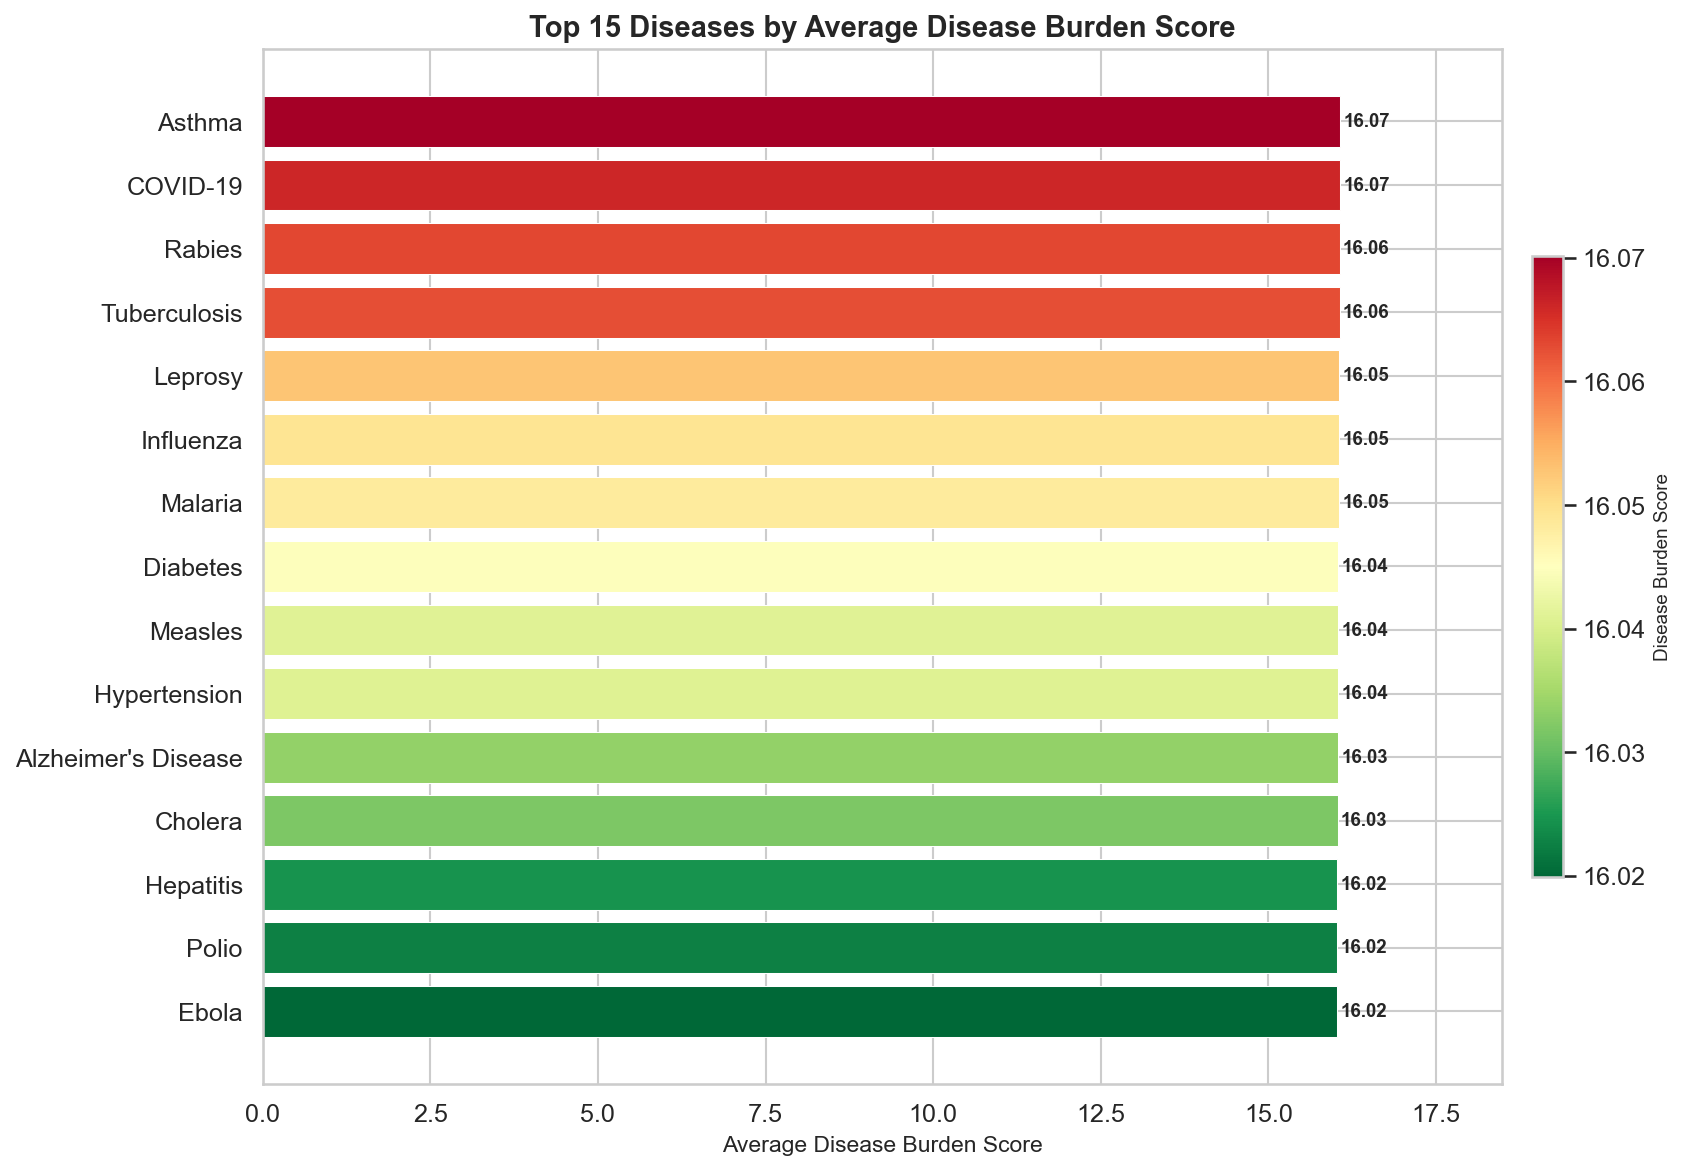

In [35]:
top_diseases = disease_summary.head(15).copy()

# Normalize scores to 0-1 for color mapping
norm = plt.Normalize(
    top_diseases['avg_burden'].min(),
    top_diseases['avg_burden'].max()
)
colors = plt.cm.RdYlGn_r(norm(top_diseases['avg_burden'].values))

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    top_diseases['disease_name'],
    top_diseases['avg_burden'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels on each bar
for bar, val in zip(bars, top_diseases['avg_burden']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}',
            va='center', ha='left', fontsize=9, fontweight='bold')

# Add colorbar to explain the color scale
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Disease Burden Score', fontsize=9)

ax.set_title('Top 15 Diseases by Average Disease Burden Score',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Disease Burden Score', fontsize=11)
ax.set_xlim(0, top_diseases['avg_burden'].max() * 1.15)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, '05_top_diseases_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### Chart 6: Scatter Plot - Per Capita Income vs Mortality Rate

✅ Sample size: 2000


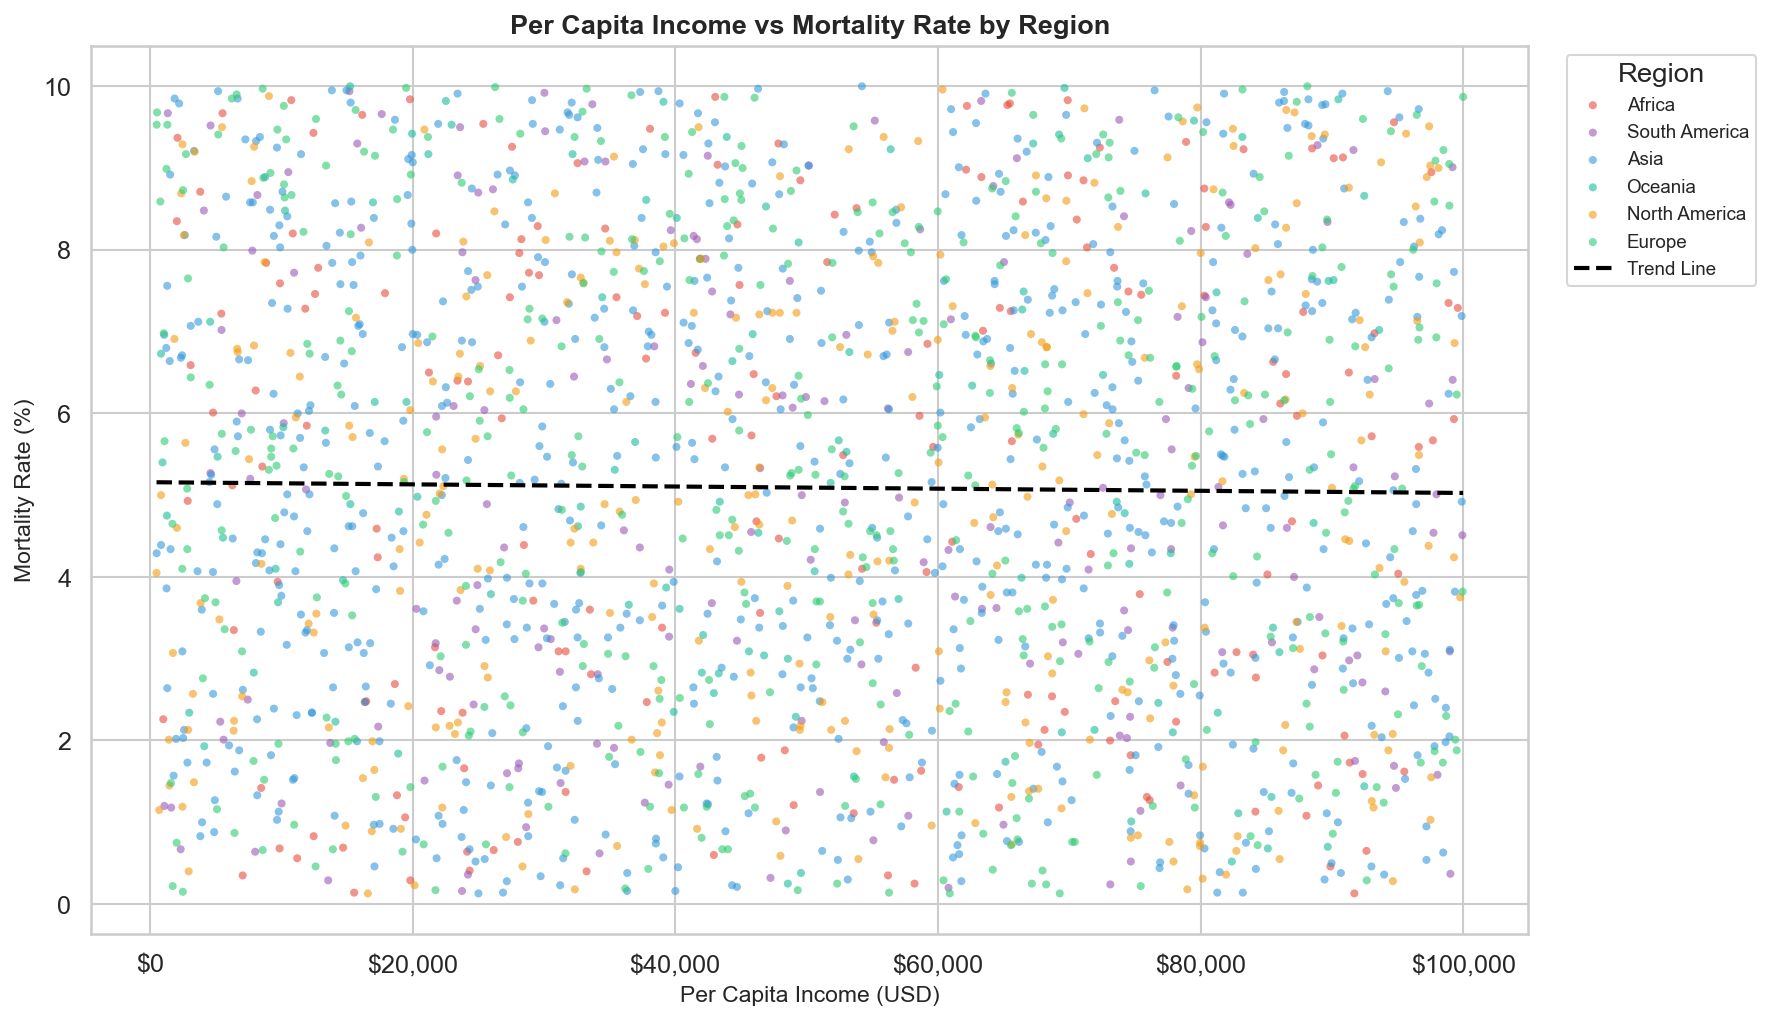

In [38]:
df_sample = df_clean.dropna(subset=[
    'per_capita_income_usd',
    'mortality_rate_%',
    'region'
]).sample(n=2000, random_state=42)

print(f"✅ Sample size: {len(df_sample)}")

fig, ax = plt.subplots(figsize=(12, 7))

colors_map = {
    'Africa':        '#e74c3c',
    'Asia':          '#3498db',
    'Europe':        '#2ecc71',
    'North America': '#f39c12',
    'South America': '#9b59b6',
    'Oceania':       '#1abc9c'
}

for region in df_sample['region'].dropna().unique():
    subset = df_sample[df_sample['region'] == region]
    ax.scatter(
        subset['per_capita_income_usd'],
        subset['mortality_rate_%'],
        c=colors_map.get(region, 'grey'),
        label=region,
        alpha=0.6,
        s=15,              # ← FIXED: small fixed dot size
        edgecolors='none'  # ← no border = cleaner look
    )

# Trend line
from numpy.polynomial.polynomial import polyfit
x = df_sample['per_capita_income_usd']
y = df_sample['mortality_rate_%']
b, m = polyfit(x, y, 1)
x_line = [x.min(), x.max()]
y_line = [b + m * xi for xi in x_line]
ax.plot(x_line, y_line,
        color='black', linestyle='--',
        linewidth=2, label='Trend Line', zorder=5)

ax.set_title('Per Capita Income vs Mortality Rate by Region',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Per Capita Income (USD)', fontsize=11)
ax.set_ylabel('Mortality Rate (%)', fontsize=11)
ax.legend(title='Region', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, '06_income_vs_mortality_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Advanced Visualizations

### ADVANCED VIZ 1: Geospatial Choropleth Map

In [50]:
fig_map = px.choropleth(
    country_summary,
    locations='country',
    locationmode='country names',
    color='avg_mortality',
    hover_name='country',
    hover_data={
        'avg_mortality': ':.2f',
        'avg_burden': ':.2f',
        'avg_treatment_gap': ':.2f'
    },
    color_continuous_scale='RdYlGn_r',
    title='Global Average Mortality Rate by Country',
    labels={'avg_mortality': 'Avg Mortality Rate (%)'}
)

fig_map.update_layout(
    title_font_size=18,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    coloraxis=dict(
        colorscale='RdYlGn_r',
        cmin=country_summary['avg_mortality'].quantile(0.1),
        cmax=country_summary['avg_mortality'].quantile(0.9),
        colorbar=dict(
            title='Mortality %',
            thickness=15,
            len=0.7
        )
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    height=500
)

fig_map.write_html(
    os.path.join(project_root, 'outputs', 'figures',
                 'advanced_01_geospatial_map.html')
)
fig_map.show()
print("Geospatial Map saved!")

Geospatial Map saved!


### ADVANCED VIZ 2: Multi-Layer Chart

In [43]:
# Aggregate by year across ALL countries
yearly_trends = (df_clean
    .groupby('year')
    .agg(
        avg_mortality        = ('mortality_rate_%', 'mean'),
        avg_healthcare_access= ('healthcare_access_%', 'mean'),
        avg_recovery         = ('recovery_rate_%', 'mean')
    )
    .reset_index()
    .sort_values('year')
)

print(" Yearly trends shape:", yearly_trends.shape)
print(yearly_trends.head())

# Build multi-layer chart
fig_multi = make_subplots(specs=[[{"secondary_y": True}]])

# --- Layer 1: Mortality Rate as BARS ---
fig_multi.add_trace(
    go.Bar(
        x=yearly_trends['year'],
        y=yearly_trends['avg_mortality'],
        name='Avg Mortality Rate (%)',
        marker_color='rgba(231, 76, 60, 0.7)',
        hovertemplate='Year: %{x}<br>Mortality: %{y:.2f}%'
    ),
    secondary_y=False
)

# --- Layer 2: Healthcare Access as LINE ---
fig_multi.add_trace(
    go.Scatter(
        x=yearly_trends['year'],
        y=yearly_trends['avg_healthcare_access'],
        name='Avg Healthcare Access (%)',
        mode='lines+markers',
        line=dict(color='royalblue', width=3),
        marker=dict(size=6),
        hovertemplate='Year: %{x}<br>Healthcare Access: %{y:.2f}%'
    ),
    secondary_y=True
)

# --- Layer 3: Recovery Rate as LINE ---
fig_multi.add_trace(
    go.Scatter(
        x=yearly_trends['year'],
        y=yearly_trends['avg_recovery'],
        name='Avg Recovery Rate (%)',
        mode='lines+markers',
        line=dict(color='green', width=3, dash='dot'),
        marker=dict(size=6),
        hovertemplate='Year: %{x}<br>Recovery: %{y:.2f}%'
    ),
    secondary_y=True
)

fig_multi.update_layout(
    title=dict(
        text=' Mortality Rate vs Healthcare Access vs Recovery Rate Over Time',
        font=dict(size=15)
    ),
    hovermode='x unified',
    legend=dict(
    orientation='h',        # horizontal legend
    yanchor='bottom',
    y=1.02,                 # sits ABOVE the chart
    xanchor='right',
    x=1
),
    plot_bgcolor='white',
    xaxis=dict(
        title='Year',
        tickmode='linear',
        dtick=1,
        gridcolor='lightgrey'
    ),
    height=500
)

fig_multi.update_yaxes(
    title_text="Avg Mortality Rate (%)",
    secondary_y=False,
    gridcolor='lightgrey'
)
fig_multi.update_yaxes(
    title_text="Healthcare Access & Recovery Rate (%)",
    secondary_y=True
)

# Save as interactive HTML
fig_multi.write_html(
    os.path.join(project_root, 'outputs', 'figures',
                 'advanced_02_multilayer.html')
)
fig_multi.show()
print(" Advanced Chart 2 saved!")

 Yearly trends shape: (25, 4)
   year  avg_mortality  avg_healthcare_access  avg_recovery
0  2000       5.054628              75.124940     74.465829
1  2001       5.038354              75.000993     74.432431
2  2002       5.045163              75.142748     74.600554
3  2003       5.050659              74.942119     74.520375
4  2004       5.055391              74.980337     74.423043


 Advanced Chart 2 saved!


### ADVANCED VIZ 3: Faceted / Small Multiple Charts

In [40]:
fig_facet = px.line(
    region_year,
    x='year',
    y='avg_mortality',
    color='region',
    facet_col='region',
    facet_col_wrap=3,
    title='📈 Mortality Rate Trends — Small Multiples by Region',
    labels={'avg_mortality': 'Avg Mortality Rate', 'year': 'Year'},
    height=700
)
fig_facet.update_layout(title_font_size=16, showlegend=False)
fig_facet.for_each_annotation(lambda a: a.update(
    text=a.text.split("=")[-1])
)
fig_facet.write_html('outputs/figures/advanced_03_faceted.html')
fig_facet.show()